In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

recruitment_df = pd.read_csv('../data/recruitment.csv', parse_dates=[
    'Applied_Date', 'Screen_Date', 'Interview_Date', 'Offer_Date', 'Start_Date'
])
employee_df = pd.read_csv('../data/employee.csv', parse_dates=[
    'Start_Date', 'Exit_Date'
])

print(recruitment_df.shape, employee_df.shape)

(900, 12) (350, 11)


In [2]:
hired_df = recruitment_df[recruitment_df['Stage_Exit'] == 'Hired'].copy() 
#copy() ile orijinal dataframe'i değiştirmeden yeni bir dataframe oluşturuyoruz

hired_df['Time_to_Fill'] = (hired_df['Start_Date'] - hired_df['Applied_Date']).dt.days

print(f"Toplam işe alım: {len(hired_df)}")
print(f"Ortalama TTF: {hired_df['Time_to_Fill'].mean():.1f} gün") # :.1f ile virgülden sonra 1 basamak gösteriyoruz
print(f"Medyan TTF: {hired_df['Time_to_Fill'].median():.1f} gün")
print(f"P90 TTF: {hired_df['Time_to_Fill'].quantile(0.90):.1f} gün")
# p90, TTF süresinin %90 ının kaç olduğunu gösterir.

Toplam işe alım: 234
Ortalama TTF: 49.4 gün
Medyan TTF: 44.5 gün
P90 TTF: 77.0 gün


In [ ]:
# Periyotlar arası TTF karşılaştırması
hired_df['Period'] = hired_df['Applied_Date'].apply(
    lambda x: 'Son 6 Ay' if x >= pd.Timestamp('2024-09-01') else 'Önceki 12 Ay'
)

period_stats = hired_df.groupby('Period')['Time_to_Fill'].agg(
    Ortalama='mean',
    Medyan='median',
    P90=lambda x: x.quantile(0.90),
    Adet='count'
).round(1)

print(period_stats)

              Ortalama  Medyan   P90  Adet
Period                                    
Son 6 Ay          70.3    69.0  93.2    68
Önceki 12 Ay      40.9    40.5  52.0   166


In [4]:
# Aşamalar arası süreler
hired_df['D_Applied_to_Screen'] = (hired_df['Screen_Date'] - hired_df['Applied_Date']).dt.days
hired_df['D_Screen_to_Interview'] = (hired_df['Interview_Date'] - hired_df['Screen_Date']).dt.days
hired_df['D_Interview_to_Offer'] = (hired_df['Offer_Date'] - hired_df['Interview_Date']).dt.days
hired_df['D_Offer_to_Start'] = (hired_df['Start_Date'] - hired_df['Offer_Date']).dt.days

stages = ['D_Applied_to_Screen', 'D_Screen_to_Interview', 'D_Interview_to_Offer', 'D_Offer_to_Start']

hired_df.groupby('Period')[stages].median().round(1)

,D_Applied_to_Screen,D_Screen_to_Interview,D_Interview_to_Offer,D_Offer_to_Start
Period,,,,
Son 6 Ay,11.0,21.5,12.0,26.0
Önceki 12 Ay,7.0,14.0,6.0,15.0


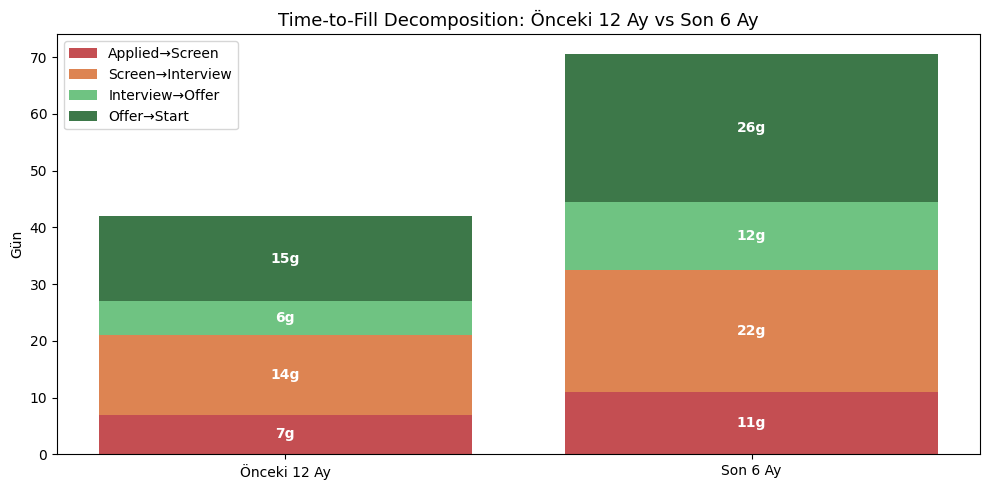

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

periods = ['Önceki 12 Ay', 'Son 6 Ay']
stage_labels = ['Applied→Screen', 'Screen→Interview', 'Interview→Offer', 'Offer→Start']
colors = ['#C44E52', '#DD8452', "#6FC382", "#3D7849"]

decomp = hired_df.groupby('Period')[stages].median().reindex(periods)

bottom = np.zeros(2)
for i, (stage, label, color) in enumerate(zip(stages, stage_labels, colors)):
    values = decomp[stage].values
    ax.bar(periods, values, bottom=bottom, label=label, color=color)
    for j, (v, b) in enumerate(zip(values, bottom)):
        ax.text(j, b + v/2, f'{v:.0f}g', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=10)
    bottom += values

ax.set_title('Time-to-Fill Decomposition: Önceki 12 Ay vs Son 6 Ay', fontsize=13)
ax.set_ylabel('Gün')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../data/ttf_decomposition.png', dpi=150)
plt.show()

In [7]:
total = len(recruitment_df)
pre_screened = total - len(recruitment_df[recruitment_df['Stage_Exit'] == 'PreScreenFail'])
interviewed = len(recruitment_df[recruitment_df['Interview_Date'].notna()])
offered = len(recruitment_df[recruitment_df['Offer_Date'].notna()])
hired = len(recruitment_df[recruitment_df['Stage_Exit'] == 'Hired'])

funnel = pd.DataFrame({
    'Aşama': ['Başvuru', 'Ön Eleme Geçti', 'Mülakata Girdi', 'Teklif Aldı', 'İşe Alındı'],
    'Adet': [total, pre_screened, interviewed, offered, hired]
})

funnel['Bir Önceki Aşamadan %'] = (funnel['Adet'] / funnel['Adet'].shift(1) * 100).round(1)
funnel['Toplam %'] = (funnel['Adet'] / total * 100).round(1)

print(funnel)

            Aşama  Adet  Bir Önceki Aşamadan %  Toplam %
0         Başvuru   900                    NaN     100.0
1  Ön Eleme Geçti   822                   91.3      91.3
2  Mülakata Girdi   663                   80.7      73.7
3     Teklif Aldı   504                   76.0      56.0
4      İşe Alındı   234                   46.4      26.0


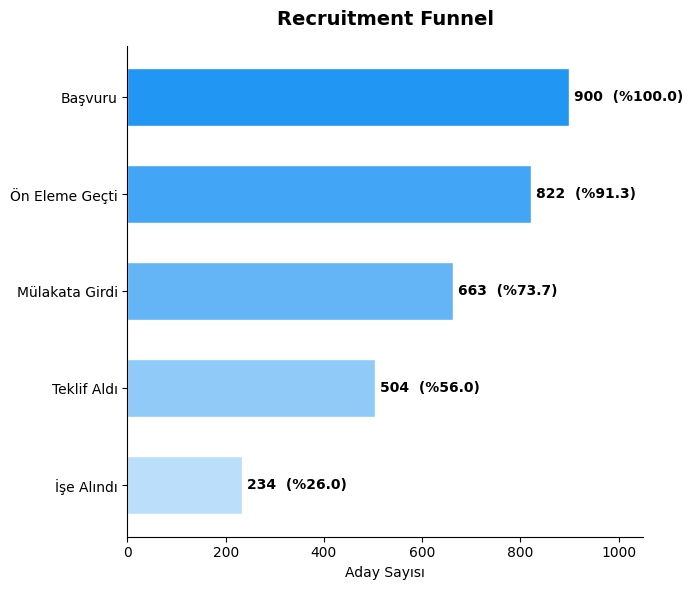

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#2196F3', '#42A5F5', '#64B5F6', '#90CAF9', '#BBDEFB']

bars = ax.barh(funnel['Aşama'], funnel['Adet'], 
               color=colors, edgecolor='white', height=0.6)

for i, (adet, oran) in enumerate(zip(funnel['Adet'], funnel['Toplam %'])):
    ax.text(adet + 10, i, f'{adet}  (%{oran})', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Aday Sayısı')
ax.set_title('Recruitment Funnel', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 1050)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/funnel.png', dpi=150)
plt.show()

In [9]:
emp = employee_df.copy()

emp['Tenure_Days'] = (emp['Exit_Date'] - emp['Start_Date']).dt.days

early_attrition = emp[emp['Tenure_Days'] <= 180].copy()
early_attrition['Early_Exit'] = 1

emp = emp.merge(early_attrition[['Employee_ID', 'Early_Exit']], on='Employee_ID', how='left')
emp['Early_Exit'] = emp['Early_Exit'].fillna(0).astype(int)

print(f"Toplam çalışan: {len(emp)}")
print(f"180 gün içinde ayrılan: {emp['Early_Exit'].sum()}")
print(f"Early attrition rate: {emp['Early_Exit'].mean()*100:.1f}%")

Toplam çalışan: 350
180 gün içinde ayrılan: 92
Early attrition rate: 26.3%


In [10]:
print("--- Role Bazında ---")
print(emp.groupby('Role')['Early_Exit'].mean().mul(100).round(1).sort_values(ascending=False))

print("\n--- Manager Bazında (Top 5) ---")
print(emp.groupby('Manager_ID')['Early_Exit'].mean().mul(100).round(1).sort_values(ascending=False).head())

print("\n--- Training Completion Bazında ---")
print(emp.groupby('Training_Completion')['Early_Exit'].mean().mul(100).round(1))

--- Role Bazında ---
Role
QualityInspector    35.1
Technician          32.8
Planner             31.3
Maintenance         25.8
SafetyOfficer       16.7
Worker              12.5
Name: Early_Exit, dtype: float64

--- Manager Bazında (Top 5) ---
Manager_ID
M003    50.0
M002    44.1
M011    37.0
M004    35.7
M012    28.0
Name: Early_Exit, dtype: float64

--- Training Completion Bazında ---
Training_Completion
0    46.5
1    19.7
Name: Early_Exit, dtype: float64


In [11]:
print("--- Manager Bazında Overtime ve Attrition ---")
manager_stats = emp.groupby('Manager_ID').agg(
    Attrition_Rate=('Early_Exit', 'mean'),
    Avg_Overtime=('Overtime_Hours_6M', 'mean'),
    Calisma_Sayisi=('Employee_ID', 'count')
).round(1)

manager_stats['Attrition_Rate'] = (manager_stats['Attrition_Rate'] * 100).round(1)
print(manager_stats.sort_values('Attrition_Rate', ascending=False).head(8))

--- Manager Bazında Overtime ve Attrition ---
            Attrition_Rate  Avg_Overtime  Calisma_Sayisi
Manager_ID                                              
M003                  50.0          85.3              32
M002                  40.0          89.1              34
M004                  40.0          23.0              28
M011                  40.0          26.9              27
M012                  30.0          30.1              25
M015                  30.0          26.1              19
M001                  20.0          77.1              12
M013                  20.0          31.6              12


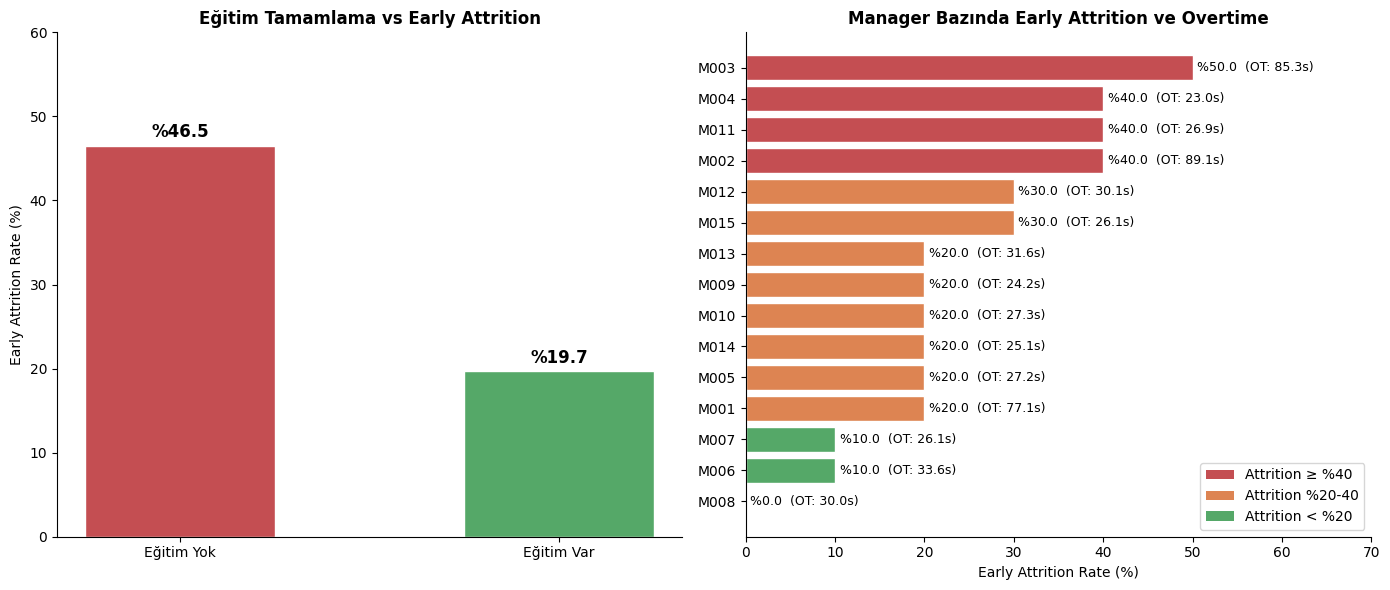

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: Training Completion vs Early Attrition
training_data = emp.groupby('Training_Completion')['Early_Exit'].mean().mul(100).round(1)
axes[0].bar(['Eğitim Yok', 'Eğitim Var'], training_data.values,
            color=['#C44E52', '#55A868'], edgecolor='white', width=0.5)
for i, v in enumerate(training_data.values):
    axes[0].text(i, v + 1, f'%{v}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Eğitim Tamamlama vs Early Attrition', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Early Attrition Rate (%)')
axes[0].set_ylim(0, 60)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Sağ: Manager bazında attrition + overtime
manager_sorted = manager_stats.sort_values('Attrition_Rate', ascending=True)
colors = ['#C44E52' if x >= 40 else '#DD8452' if x >= 20 else '#55A868'
          for x in manager_sorted['Attrition_Rate']]

axes[1].barh(manager_sorted.index, manager_sorted['Attrition_Rate'],
             color=colors, edgecolor='white')
for i, (rate, overtime) in enumerate(zip(manager_sorted['Attrition_Rate'],
                                          manager_sorted['Avg_Overtime'])):
    axes[1].text(rate + 0.5, i, f'%{rate}  (OT: {overtime}s)', va='center', fontsize=9)

axes[1].set_xlabel('Early Attrition Rate (%)')
axes[1].set_title('Manager Bazında Early Attrition ve Overtime', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 70)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C44E52', label='Attrition ≥ %40'),
                   Patch(facecolor='#DD8452', label='Attrition %20-40'),
                   Patch(facecolor='#55A868', label='Attrition < %20')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../data/attrition_analysis.png', dpi=150)
plt.show()

In [13]:
offer_df = recruitment_df[recruitment_df['Offer_Date'].notna()]

offer_acceptance = offer_df.groupby('Source').apply(
    lambda x: (x['Stage_Exit'] == 'Hired').sum() / len(x) * 100
).round(1)

print(offer_acceptance)

Source
Agency         5.3
Internal      51.2
JobFair       44.4
LinkedIn      57.0
Referral      62.3
University    54.5
dtype: float64


C:\Users\Enes\AppData\Local\Temp\ipykernel_7800\710489028.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  offer_acceptance = offer_df.groupby('Source').apply(


In [14]:
recruitment_df.groupby('Source')['Stage_Exit'].value_counts(normalize=True).unstack().round(2)[['Hired', 'OfferDeclined']]

Stage_Exit,Hired,OfferDeclined
Source,,
Agency,0.03,0.27
Internal,0.29,0.17
JobFair,0.27,0.20
LinkedIn,0.33,0.08
Referral,0.33,0.06
University,0.32,0.12
